In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv('extracted_data/master_dataset.csv',
           parse_dates=['order_purchase_timestamp','order_delivered_customer_date',
                        'order_estimated_delivery_date'])

In [5]:
df.shape[0]

118434

## Analysis 1 -> Monthly Sales Trend

In [9]:
# month-year column 
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')
df['order_month'] 

0         2017-10
1         2017-10
2         2017-10
3         2018-07
4         2018-08
           ...   
118429    2018-02
118430    2017-08
118431    2018-01
118432    2018-01
118433    2018-03
Name: order_month, Length: 118434, dtype: period[M]

In [19]:
# Monthly revenue

monthly_sales= df.groupby('order_month')['payment_value'].sum().reset_index()
monthly_sales['order_month'] = monthly_sales['order_month'].astype(str)

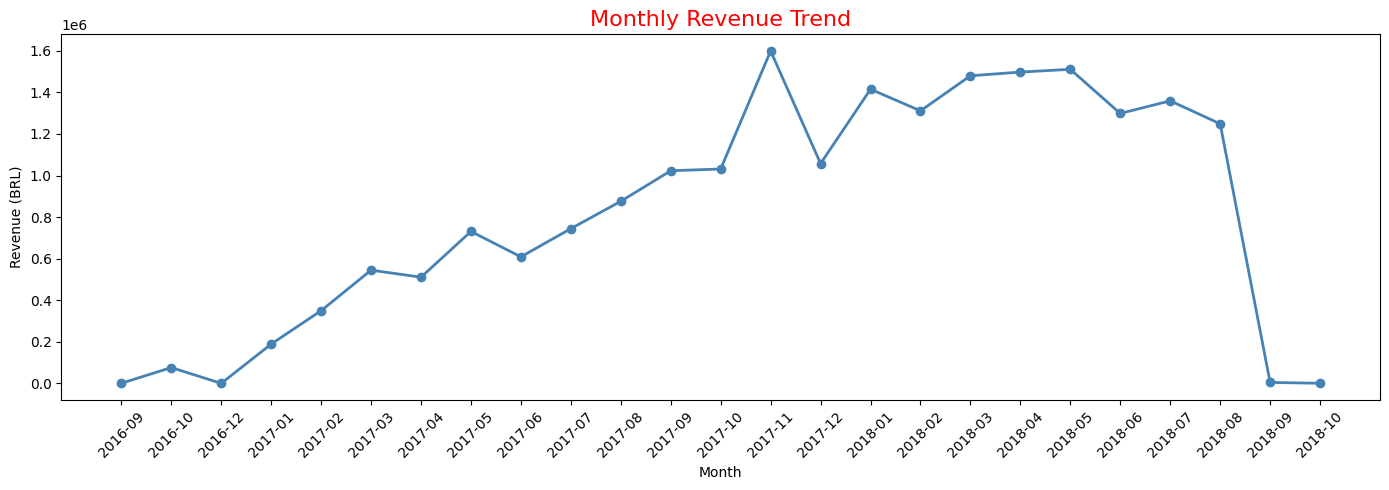


 Top 5 Revenue Months:
   order_month  payment_value
13     2017-11     1599444.18
19     2018-05     1511113.00
18     2018-04     1497843.94
17     2018-03     1480045.50
15     2018-01     1415348.54


In [45]:
# Plot
plt.figure(figsize=(14,5))
plt.plot(monthly_sales['order_month'],
        monthly_sales['payment_value'],
        marker='o',color='steelblue',linewidth=2)
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend',fontsize=16,color='red')
plt.xlabel('Month')
plt.ylabel('Revenue (BRL)')
plt.tight_layout()
plt.show()
print("\n Top 5 Revenue Months:")
print(monthly_sales.nlargest(5,'payment_value'))

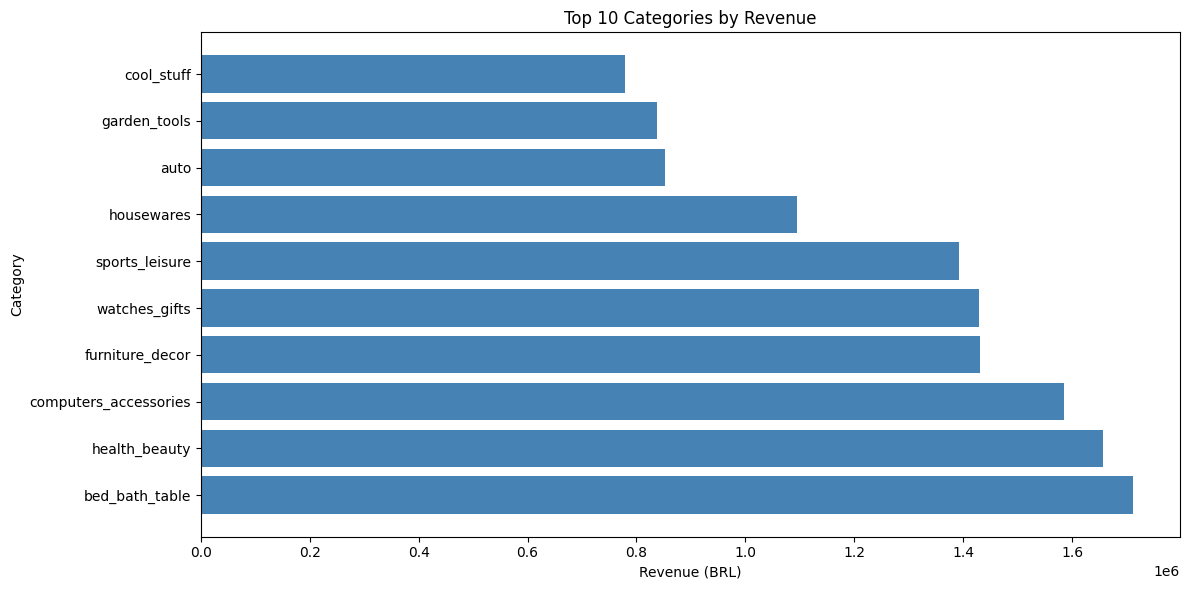


 Top 10 Categories:
  product_category_name_english  payment_value
0                bed_bath_table     1712553.67
1                 health_beauty     1657373.12
2         computers_accessories     1585330.45
3               furniture_decor     1430176.39
4                 watches_gifts     1429216.68
5                sports_leisure     1392127.56
6                    housewares     1094758.13
7                          auto      852294.33
8                  garden_tools      838280.75
9                    cool_stuff      779698.00


In [41]:
# categories by revenu
top_categories = df.groupby('product_category_name_english')['payment_value'].sum()\
                   .nlargest(10)\
                   .reset_index()

plt.figure(figsize=(12, 6))
plt.barh(top_categories['product_category_name_english'], 
         top_categories['payment_value'],
         color='steelblue')
plt.title('Top 10 Categories by Revenue')
plt.xlabel('Revenue (BRL)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

print("\n Top 10 Categories:")
print(top_categories)

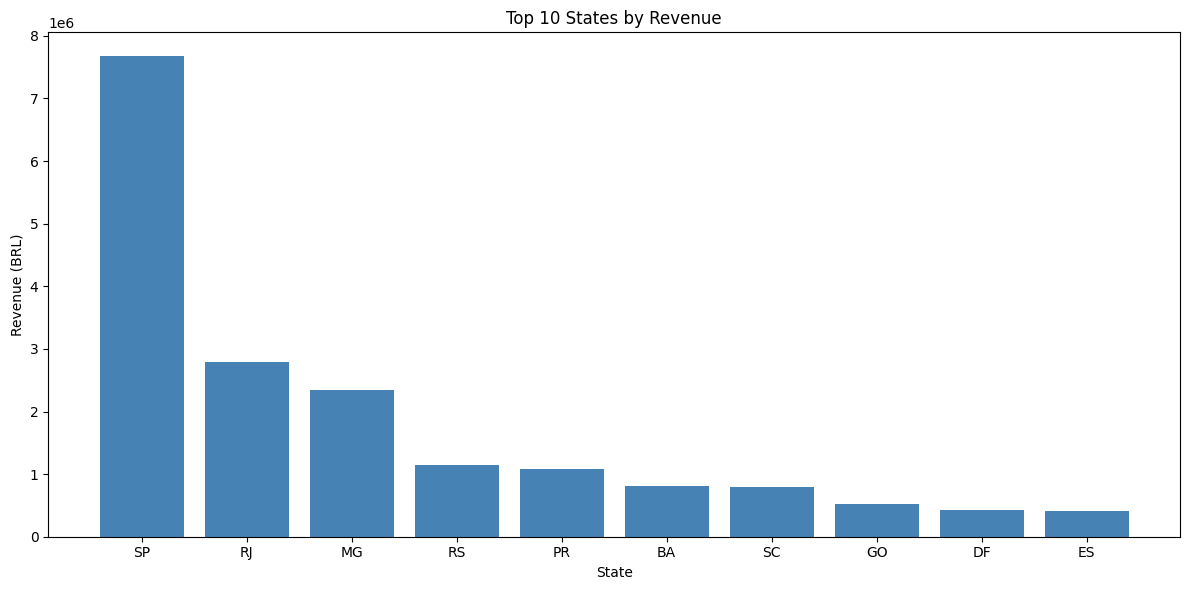


 Top 10 States:
  customer_state  payment_value
0             SP     7673188.55
1             RJ     2783724.26
2             MG     2341861.47
3             RS     1152019.17
4             PR     1074614.19
5             BA      802416.72
6             SC      799135.92
7             GO      516182.51
8             DF      434512.55
9             ES      406946.26


In [46]:
# Top 10 states by revenue
top_states = df.groupby('customer_state')['payment_value']\
               .sum()\
               .nlargest(10)\
               .reset_index()

plt.figure(figsize=(12, 6))
plt.bar(top_states['customer_state'], 
        top_states['payment_value'],
        color='steelblue')
plt.title('Top 10 States by Revenue')
plt.xlabel('State')
plt.ylabel('Revenue (BRL)')
plt.tight_layout()
plt.show()

print("\n Top 10 States:")
print(top_states)

In [56]:
reviews = pd.read_csv('extracted_data/olist_order_reviews_dataset.csv')

0         4.0
1         4.0
2         4.0
3         4.0
4         5.0
         ... 
119138    4.0
119139    5.0
119140    2.0
119141    2.0
119142    5.0
Name: review_score, Length: 119143, dtype: float64

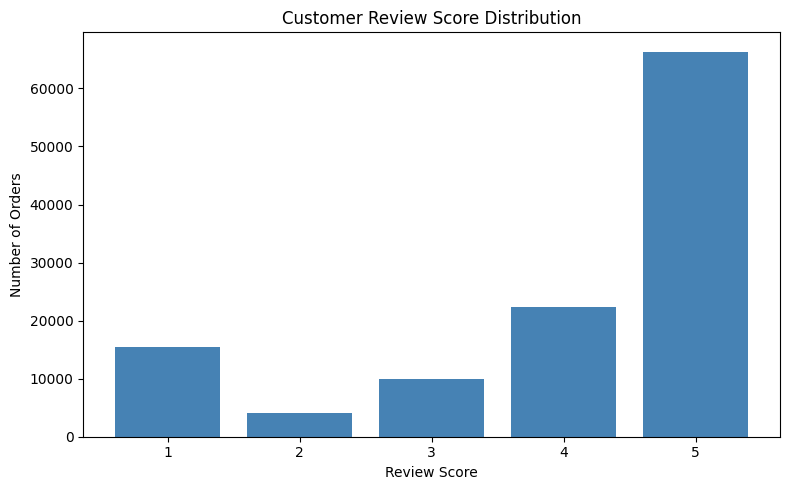


 Review Score Distribution:
review_score
1.0    15428
2.0     4162
3.0     9894
4.0    22319
5.0    66343
Name: count, dtype: int64

Average Review Score: 4.02


In [63]:
# Review score distribution
review_dist = df['review_score'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(review_dist.index, 
        review_dist.values,
        color='steelblue')
plt.title('Customer Review Score Distribution')
plt.xlabel('Review Score')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

print("\n Review Score Distribution:")
print(review_dist)
print(f"\nAverage Review Score: {df['review_score'].mean():.2f}")

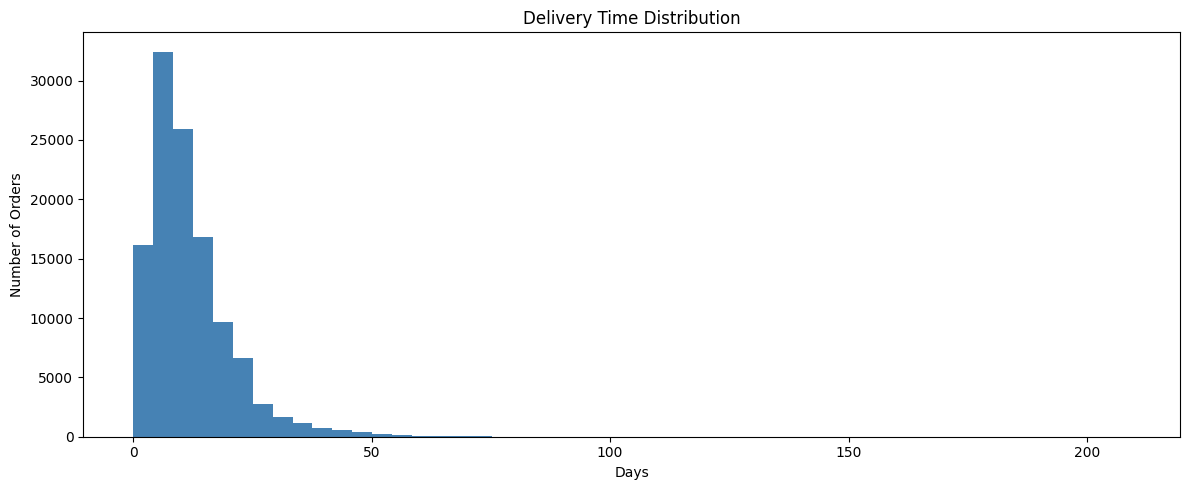

Average Delivery Time: 12.0 days
Fastest Delivery: 0 days
Slowest Delivery: 209 days


In [64]:
# Delivery time calculate karo
df['delivery_time'] = (df['order_delivered_customer_date'] - 
                       df['order_purchase_timestamp']).dt.days

# Sirf delivered orders lo
delivered = df[df['delivery_time'].notna()]

plt.figure(figsize=(12, 5))
plt.hist(delivered['delivery_time'], 
         bins=50, 
         color='steelblue')
plt.title('Delivery Time Distribution')
plt.xlabel('Days')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

print(f"Average Delivery Time: {delivered['delivery_time'].mean():.1f} days")
print(f"Fastest Delivery: {delivered['delivery_time'].min():.0f} days")
print(f"Slowest Delivery: {delivered['delivery_time'].max():.0f} days")